# Accuracy benchmark — FINd_optimized vs pHash vs wHash

Goal: compare the three perceptual hashes on the meme_images dataset (1035 ground-truth clusters of ≥10 near-duplicates each). Headline metric is **TPR @ FPR=1%** — the business-aligned framing for content moderation (use case A, evaluation_criteria.md §1).

Sections:
1. Setup + cluster index.
2. Stratified pair sample (1000 within + 1000 between).
3. Hash all unique images (3 methods × 256-bit).
4. Pair distances.
5. Distribution analysis (within vs between).
6. ROC curves + AUC.
7. Operating-points table (TPR @ FPR ∈ {0.1%, 0.5%, 1%, 5%}).
8. Computational cost comparison (latency on N=100).
9. Summary JSON + acceptance-bar auto-fill.
10. HTML report export.

Method choices:
- **FINd_optimized** — our numpy-vectorised hasher.
- **pHash (256-bit)** — DCT-based; literature anchor for criteria A1/A2.
- **wHash (256-bit, Haar)** — wavelet-based; methodologically distinct (different math basis vs FINd's DCT).

## 1. Setup

In [1]:
import sys, os, json, random, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import imagehash

_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == 'notebooks' else _here
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from FINd_optimized import FINDHasherOptimized

IMG_DIR = PROJECT_ROOT / 'meme_images'
FIG_DIR = PROJECT_ROOT / 'figures' / 'accuracy'
SUMMARIES_DIR = PROJECT_ROOT / 'summaries'
FIG_DIR.mkdir(parents=True, exist_ok=True)
SUMMARIES_DIR.mkdir(exist_ok=True)

SEED = 99
PAIRS_PER_CLUSTER = 5
N_WITHIN_CLUSTERS = 200       # 200 × 5 = 1000 within-pairs
N_BETWEEN_REPRESENTATIVES = 500  # 500 reps → sample 1000 between-pairs
N_BETWEEN_PAIRS = 1000

print(f'Project root: {PROJECT_ROOT}')
print(f'imagehash version: {imagehash.__version__}')

Project root: /Users/alena/ms_ox/sds/summative2026
imagehash version: 4.3.2


## 2. Cluster index + stratified pair sample

The dataset filename convention is `XXXX_NNNNNNNN.jpg` where `XXXX` is the cluster ID. Same-cluster pairs are presumed near-duplicates (ground-truth positive); different-cluster pairs are presumed non-duplicates (ground-truth negative).

**Stratified sampling rationale**: cluster sizes range 10–766. Random within-pair sampling would over-represent large clusters (more pairs per cluster). Stratified sampling — fixed pairs per cluster, fixed reps per between-cluster — gives equal weight to each meme family.

In [2]:
# Build cluster index: cluster_id -> list of filenames
clusters = defaultdict(list)
for f in sorted(os.listdir(IMG_DIR)):
    cluster_id = f.split('_')[0]
    clusters[cluster_id].append(f)

n_clusters = len(clusters)
sizes = [len(v) for v in clusters.values()]
print(f'Total clusters: {n_clusters}')
print(f'Cluster size: min={min(sizes)}, median={int(np.median(sizes))}, max={max(sizes)}')

rng = random.Random(SEED)

# WITHIN pairs: stratified — 5 random pairs from each of 200 random clusters
all_cluster_ids = list(clusters.keys())
rng.shuffle(all_cluster_ids)
within_cluster_ids = all_cluster_ids[:N_WITHIN_CLUSTERS]

within_pairs = []
for cid in within_cluster_ids:
    files = clusters[cid]
    # All possible pairs in this cluster
    all_pairs = [(files[i], files[j]) for i in range(len(files)) for j in range(i+1, len(files))]
    sampled = rng.sample(all_pairs, min(PAIRS_PER_CLUSTER, len(all_pairs)))
    for a, b in sampled:
        within_pairs.append((a, b, cid, cid))

# BETWEEN pairs: pick 1 representative per cluster from a different 500 clusters,
# then sample 1000 pairs from C(500, 2) = 124,750 possibilities
between_cluster_ids = all_cluster_ids[N_WITHIN_CLUSTERS:N_WITHIN_CLUSTERS + N_BETWEEN_REPRESENTATIVES]
representatives = {cid: rng.choice(clusters[cid]) for cid in between_cluster_ids}

between_pairs_pool = [
    (representatives[a], representatives[b], a, b)
    for i, a in enumerate(between_cluster_ids)
    for b in between_cluster_ids[i+1:]
]
between_pairs = rng.sample(between_pairs_pool, min(N_BETWEEN_PAIRS, len(between_pairs_pool)))

print(f'WITHIN pairs:  {len(within_pairs)}  (from {N_WITHIN_CLUSTERS} clusters × ≤{PAIRS_PER_CLUSTER} pairs)')
print(f'BETWEEN pairs: {len(between_pairs)} (from {N_BETWEEN_REPRESENTATIVES} representatives, sampled from C({N_BETWEEN_REPRESENTATIVES},2))')

# Collect all unique filenames we need to hash
unique_files = set()
for a, b, _, _ in within_pairs + between_pairs:
    unique_files.add(a); unique_files.add(b)
unique_files = sorted(unique_files)
print(f'Unique images to hash: {len(unique_files)}')

Total clusters: 1035
Cluster size: min=10, median=24, max=766


WITHIN pairs:  1000  (from 200 clusters × ≤5 pairs)
BETWEEN pairs: 1000 (from 500 representatives, sampled from C(500,2))
Unique images to hash: 2176


## 3. Hash all unique images — three methods × 256-bit

We hash each unique file once per method and cache. Pair-level distances are then computed as `hash[a] - hash[b]` (Hamming, via `imagehash.ImageHash.__sub__`).

All three methods use **256-bit hashes** (16×16) for apples-to-apples comparison:
- FINd_optimized: native 256-bit
- pHash: `hash_size=16` (DCT 16×16)
- wHash: `hash_size=16, mode='haar'` (Haar wavelet 16×16)

In [3]:
find = FINDHasherOptimized()

methods = {
    'find':  lambda path: find.fromFile(str(path)),
    'phash': lambda path: imagehash.phash(Image.open(path), hash_size=16),
    'whash': lambda path: imagehash.whash(Image.open(path), hash_size=16, mode='haar'),
}

hashes = {m: {} for m in methods}
timing = {m: 0.0 for m in methods}

for m, fn in methods.items():
    t0 = time.perf_counter()
    for f in unique_files:
        hashes[m][f] = fn(IMG_DIR / f)
    timing[m] = time.perf_counter() - t0
    print(f'{m:6s}: hashed {len(unique_files)} images in {timing[m]:.2f}s ({timing[m]/len(unique_files)*1000:.2f} ms/img)')

find  : hashed 2176 images in 12.23s (5.62 ms/img)


phash : hashed 2176 images in 4.55s (2.09 ms/img)


whash : hashed 2176 images in 10.36s (4.76 ms/img)


## 4. Pair distances → DataFrame for analysis

In [4]:
rows = []
for (a, b, ca, cb), label in [(p, 'within') for p in within_pairs] + [(p, 'between') for p in between_pairs]:
    row = {'file_a': a, 'file_b': b, 'cluster_a': ca, 'cluster_b': cb, 'label': label}
    for m in methods:
        row[f'd_{m}'] = hashes[m][a] - hashes[m][b]
    rows.append(row)
df = pd.DataFrame(rows)
df.head()

,file_a,file_b,cluster_a,cluster_b,label,d_find,d_phash,d_whash
0,0555_13551459.jpg,0555_13554694.jpg,0555,0555,within,98,86,50
1,0555_14141165.jpg,0555_17674094.jpg,0555,0555,within,66,66,50
2,0555_13552952.jpg,0555_14141165.jpg,0555,0555,within,88,86,50
3,0555_14141336.jpg,0555_34600335.jpg,0555,0555,within,78,70,40
4,0555_13550735.jpg,0555_34507392.jpg,0555,0555,within,78,72,46


In [5]:
# Save raw pair distances for reproducibility / further analysis
df.to_csv(SUMMARIES_DIR / 'accuracy_pairs.csv', index=False)
print(f'Saved {len(df)} pair distances → summaries/accuracy_pairs.csv')

Saved 2000 pair distances → summaries/accuracy_pairs.csv


## 5. Distribution analysis — within vs between

Discrimination = `mean_between - mean_within` (criteria A3 ≥ 50 bits).

A larger gap means easier threshold-based classification.

In [6]:
dist_stats = []
for m in methods:
    within_d  = df[df.label == 'within'][f'd_{m}']
    between_d = df[df.label == 'between'][f'd_{m}']
    dist_stats.append({
        'method': m,
        'mean_within': within_d.mean(),
        'mean_between': between_d.mean(),
        'discrimination': between_d.mean() - within_d.mean(),
        'std_within': within_d.std(),
        'std_between': between_d.std(),
        'min_between': between_d.min(),
        'max_within': within_d.max(),
        'overlap_zone': max(0, within_d.max() - between_d.min()),
    })
dist_df = pd.DataFrame(dist_stats).set_index('method')
print(dist_df.round(2).to_string())

        mean_within  mean_between  discrimination  std_within  std_between  min_between  max_within  overlap_zone
method                                                                                                           
find          54.68        127.25           72.57       22.04         8.94          102         136            34
phash         51.89        126.45           74.56       21.71         8.80           98         134            36
whash         30.33        126.52           96.20       19.96        22.67           46         142            96


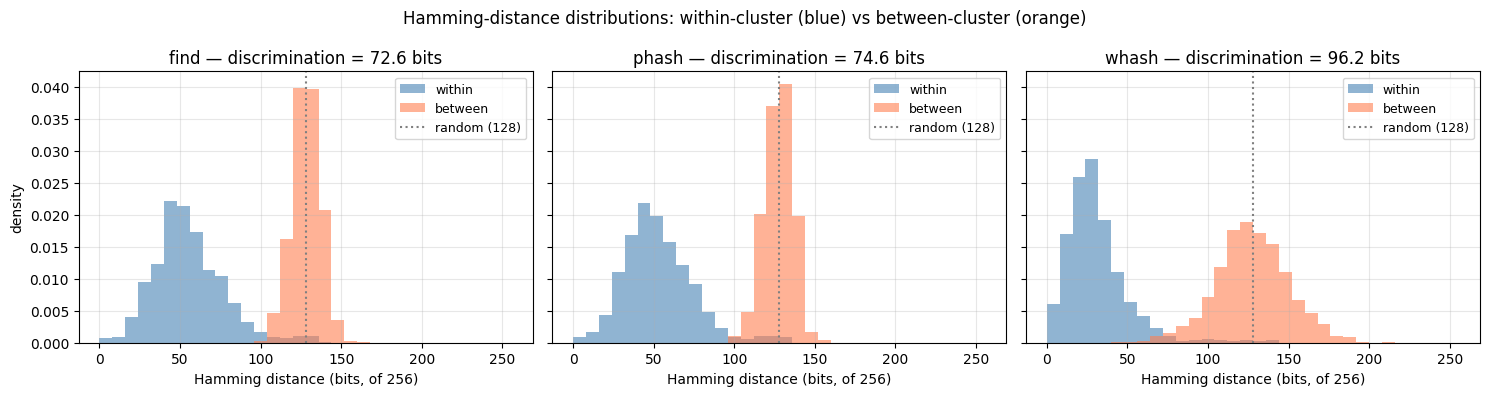

In [7]:
# Distribution overlay: 3 methods × (within / between)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, m in zip(axes, methods):
    within_d  = df[df.label == 'within'][f'd_{m}']
    between_d = df[df.label == 'between'][f'd_{m}']
    bins = np.arange(0, 257, 8)
    ax.hist(within_d,  bins=bins, alpha=0.6, label='within',  color='steelblue', density=True)
    ax.hist(between_d, bins=bins, alpha=0.6, label='between', color='coral', density=True)
    ax.axvline(128, color='gray', linestyle=':', label='random (128)')
    ax.set_xlabel('Hamming distance (bits, of 256)')
    ax.set_title(f'{m} — discrimination = {dist_df.loc[m, "discrimination"]:.1f} bits')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel('density')
fig.suptitle('Hamming-distance distributions: within-cluster (blue) vs between-cluster (orange)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Distribution + calibration overlay

The same distributions plot as section 5, but with **vertical lines marking the three confidence-bucket thresholds** (50 / 90 / 130 bits). This makes the connection explicit: a `distance < 50` cuts off most of the within-cluster mass while leaving almost no between-cluster mass to its left — that's why we recommend it as the «high precision» bucket.

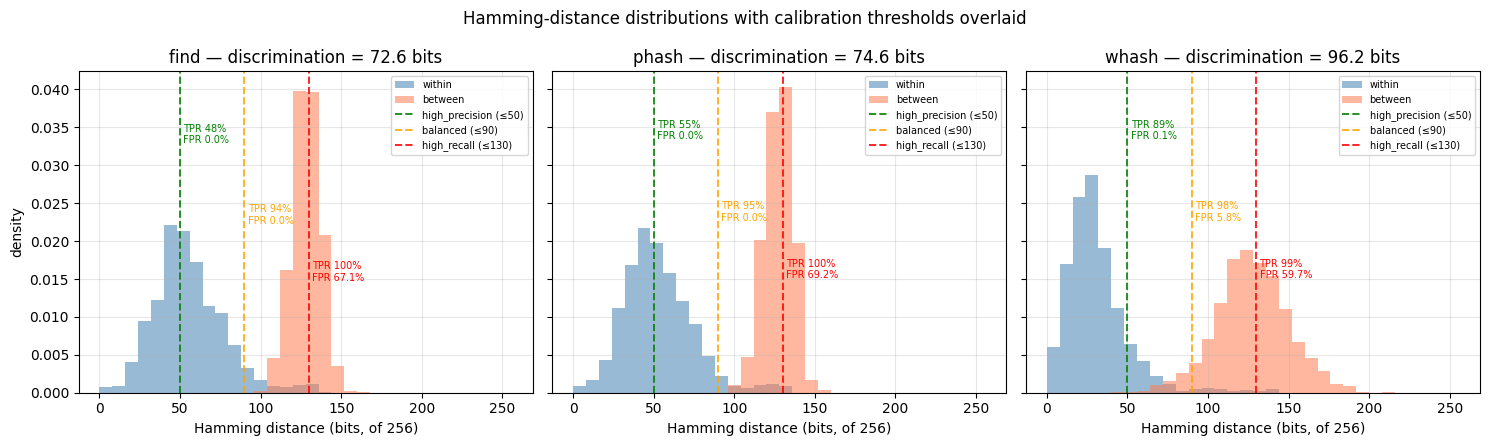

In [8]:
# Distribution overlay with calibration lines
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

bucket_thresholds = [(50, 'high_precision', 'green'),
                     (90, 'balanced', 'orange'),
                     (130, 'high_recall', 'red')]

for ax, m in zip(axes, methods):
    within_d  = df[df.label == 'within'][f'd_{m}']
    between_d = df[df.label == 'between'][f'd_{m}']
    bins = np.arange(0, 257, 8)
    ax.hist(within_d,  bins=bins, alpha=0.55, label='within',  color='steelblue', density=True)
    ax.hist(between_d, bins=bins, alpha=0.55, label='between', color='coral', density=True)

    # Calibration lines + bucket region annotations
    for thr, name, color in bucket_thresholds:
        ax.axvline(thr, color=color, linestyle='--', linewidth=1.4, alpha=0.85,
                   label=f'{name} (≤{thr})')

    # Compute and annotate FPR / TPR at each threshold
    annotation_y = ax.get_ylim()[1] * 0.85
    for thr, name, color in bucket_thresholds:
        tpr = (within_d  <= thr).mean()
        fpr = (between_d <= thr).mean()
        ax.text(thr + 2, annotation_y, f'TPR {tpr:.0%}\nFPR {fpr*100:.1f}%',
                fontsize=7, color=color, va='top')
        annotation_y *= 0.7  # stagger so they don't overlap

    ax.set_xlabel('Hamming distance (bits, of 256)')
    ax.set_title(f'{m} — discrimination = {dist_df.loc[m, "discrimination"]:.1f} bits')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=7)

axes[0].set_ylabel('density')
fig.suptitle('Hamming-distance distributions with calibration thresholds overlaid')
fig.tight_layout()
fig.savefig(FIG_DIR / 'distributions_calibrated.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ROC curves + AUC

Vary the threshold from 0 to 256 bits; for each threshold compute TPR (recall on near-duplicates) and FPR (false alarms on different memes).

ROC integrates these into a single quality measure (AUC). Higher AUC = better overall discrimination.

find  : AUC = 0.9897
phash : AUC = 0.9907
whash : AUC = 0.9921


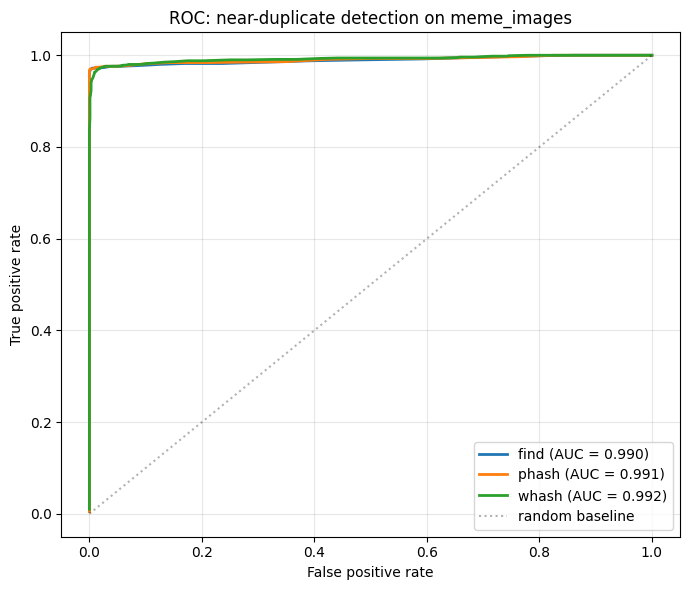

In [9]:
def roc_curve(within_d, between_d):
    """Sort distances, sweep threshold, compute (FPR, TPR) for each."""
    thresholds = np.arange(0, 257)  # bit thresholds
    tpr = np.array([(within_d  <= t).mean() for t in thresholds])
    fpr = np.array([(between_d <= t).mean() for t in thresholds])
    auc = np.trapezoid(tpr, fpr)  # area under ROC
    return thresholds, tpr, fpr, auc

roc_data = {}
for m in methods:
    within_d  = df[df.label == 'within'][f'd_{m}'].values
    between_d = df[df.label == 'between'][f'd_{m}'].values
    thresholds, tpr, fpr, auc = roc_curve(within_d, between_d)
    roc_data[m] = {'thresholds': thresholds, 'tpr': tpr, 'fpr': fpr, 'auc': auc}
    print(f'{m:6s}: AUC = {auc:.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
for m in methods:
    r = roc_data[m]
    ax.plot(r['fpr'], r['tpr'], '-', label=f'{m} (AUC = {r["auc"]:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k:', alpha=0.3, label='random baseline')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC: near-duplicate detection on meme_images')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'roc.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 ROC zoom-in + calibration overlay

The full-scale ROC plot above shows that all three methods are excellent (AUC > 0.989) — but at this scale the curves are squashed against the top-left corner and it's impossible to see how they actually differ.

This zoom-in into the **operational region** (FPR 0–5 %, TPR 0.85–1.0) is where real deployment decisions live. Vertical reference lines mark the three threshold-recommendation points (`high_precision = 50`, `balanced = 90`, `high_recall = 130`) used by the API and surfaced to FIN clients.

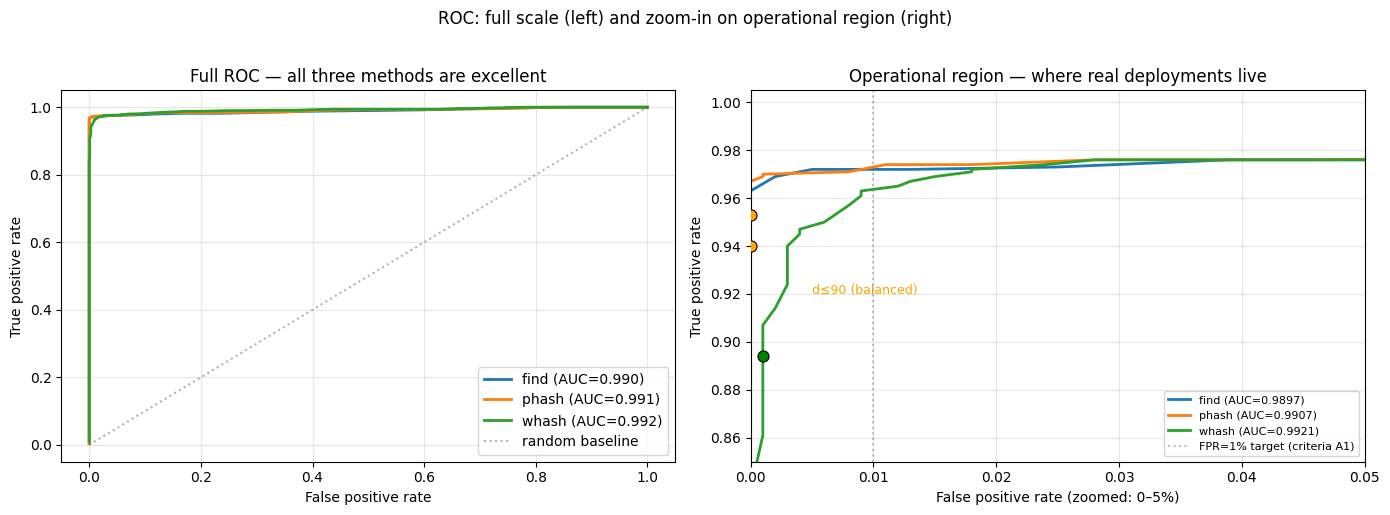


Operating points at recommended thresholds (FPR / TPR per method):
method   high_prec (≤50)        balanced (≤90)         high_recall (≤130)    
find     FPR=0.00%, TPR=48.0%   FPR=0.00%, TPR=94.0%   FPR=67.10%, TPR=99.5% 
phash    FPR=0.00%, TPR=55.2%   FPR=0.00%, TPR=95.3%   FPR=69.20%, TPR=99.5% 
whash    FPR=0.10%, TPR=89.4%   FPR=5.80%, TPR=97.7%   FPR=59.70%, TPR=99.4% 


In [10]:
# ROC zoom-in: focus on operational region (FPR ≤ 5%) where real thresholds live
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full-scale ROC (replica for context)
for m in methods:
    r = roc_data[m]
    axes[0].plot(r['fpr'], r['tpr'], '-', label=f'{m} (AUC={r["auc"]:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k:', alpha=0.3, label='random baseline')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('Full ROC — all three methods are excellent')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Right: zoom-in on operational region (FPR 0-5%)
ax = axes[1]
threshold_colors = {'high_precision (50)': 'green', 'balanced (90)': 'orange', 'high_recall (130)': 'red'}
threshold_distances = {'high_precision (50)': 50, 'balanced (90)': 90, 'high_recall (130)': 130}

for m in methods:
    r = roc_data[m]
    ax.plot(r['fpr'], r['tpr'], '-', label=f'{m} (AUC={r["auc"]:.4f})', linewidth=2)
    # Mark each threshold point on the curve
    for label, dist in threshold_distances.items():
        if dist <= 256:
            tpr_at_d = (df[df.label == 'within'][f'd_{m}'] <= dist).mean()
            fpr_at_d = (df[df.label == 'between'][f'd_{m}'] <= dist).mean()
            ax.plot(fpr_at_d, tpr_at_d, 'o', color=threshold_colors[label],
                    markersize=8, markeredgecolor='black', markeredgewidth=0.8,
                    zorder=10)

# Annotate operating points (only on FINd curve to avoid clutter)
for label, dist in threshold_distances.items():
    fpr_at_d = (df[df.label == 'between']['d_find'] <= dist).mean()
    tpr_at_d = (df[df.label == 'within']['d_find'] <= dist).mean()
    if fpr_at_d <= 0.05 and tpr_at_d >= 0.85:
        ax.annotate(f'd≤{dist} ({label.split(" ")[0]})',
                    xy=(fpr_at_d, tpr_at_d),
                    xytext=(fpr_at_d + 0.005, tpr_at_d - 0.02),
                    fontsize=9, color=threshold_colors[label])

ax.axvline(0.01, color='gray', linestyle=':', alpha=0.5, label='FPR=1% target (criteria A1)')
ax.set_xlim(0, 0.05)
ax.set_ylim(0.85, 1.005)
ax.set_xlabel('False positive rate (zoomed: 0–5%)')
ax.set_ylabel('True positive rate')
ax.set_title('Operational region — where real deployments live')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle('ROC: full scale (left) and zoom-in on operational region (right)', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'roc_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# Print operating points table (anchored to thresholds)
print('\nOperating points at recommended thresholds (FPR / TPR per method):')
print(f"{'method':<8} {'high_prec (≤50)':<22} {'balanced (≤90)':<22} {'high_recall (≤130)':<22}")
for m in methods:
    cells = []
    for label, dist in threshold_distances.items():
        fpr_at_d = (df[df.label == 'between'][f'd_{m}'] <= dist).mean()
        tpr_at_d = (df[df.label == 'within'][f'd_{m}'] <= dist).mean()
        cells.append(f'FPR={fpr_at_d*100:.2f}%, TPR={tpr_at_d*100:.1f}%')
    print(f'{m:<8} {cells[0]:<22} {cells[1]:<22} {cells[2]:<22}')

## 7. Operating-points table — TPR @ FPR ∈ {0.1%, 0.5%, 1%, 5%}

**Headline business metric**: TPR @ FPR=1% — what fraction of true near-duplicates do we catch when 1% false positives is acceptable (FIN's downstream human review absorbs that rate)?

This directly maps to evaluation_criteria.md A1 ("TPR ≥ 80% absolute + ≥ pHash − 5pp").

In [11]:
def tpr_at_fpr(roc, target_fpr):
    """Find max TPR achievable while keeping FPR ≤ target_fpr."""
    mask = roc['fpr'] <= target_fpr
    if not mask.any():
        return 0.0, None
    valid_tpr = roc['tpr'][mask]
    valid_thr = roc['thresholds'][mask]
    idx = np.argmax(valid_tpr)
    return float(valid_tpr[idx]), int(valid_thr[idx])

target_fprs = [0.001, 0.005, 0.01, 0.05]
op_rows = []
for m in methods:
    row = {'method': m, 'AUC': roc_data[m]['auc']}
    for fpr_target in target_fprs:
        tpr_val, thr = tpr_at_fpr(roc_data[m], fpr_target)
        row[f'TPR @ FPR={fpr_target*100:.1f}% (thr)'] = f'{tpr_val:.3f} (≤{thr})'
    op_rows.append(row)
op_df = pd.DataFrame(op_rows).set_index('method')
print(op_df.to_string())
print()
print('HEADLINE: TPR @ FPR=1% (the business-aligned bar):')
for m in methods:
    tpr_val, thr = tpr_at_fpr(roc_data[m], 0.01)
    print(f'  {m:6s}: {tpr_val*100:.1f}%  (threshold ≤ {thr} bits)')

             AUC TPR @ FPR=0.1% (thr) TPR @ FPR=0.5% (thr) TPR @ FPR=1.0% (thr) TPR @ FPR=5.0% (thr)
method                                                                                              
find    0.989691         0.963 (≤100)         0.972 (≤104)         0.972 (≤104)         0.976 (≤110)
phash   0.990664         0.970 (≤100)         0.970 (≤100)         0.971 (≤102)         0.976 (≤108)
whash   0.992075          0.907 (≤53)          0.947 (≤62)          0.963 (≤69)          0.976 (≤80)

HEADLINE: TPR @ FPR=1% (the business-aligned bar):
  find  : 97.2%  (threshold ≤ 104 bits)
  phash : 97.1%  (threshold ≤ 102 bits)
  whash : 96.3%  (threshold ≤ 69 bits)


## 7.5 Per-cluster + method-agreement analysis

Aggregate metrics (TPR, AUC, mean discrimination) treat all clusters as equivalent. In reality, some meme families are easy for the algorithm (mean within-distance ~30 bits), others are genuinely hard (~90 bits — close to the random baseline). This section drills into:

1. **Cluster difficulty distribution** — which clusters does FINd find hardest?
2. **Method agreement** — when methods disagree on a within-pair, which one is right?
3. **Outliers** — within-pairs with surprisingly high distance (algorithmic failure or label noise?)

In [12]:
# Per-cluster within-distance stats — hardest meme families
within = df[df.label == 'within'].copy()

cluster_stats = (
    within.groupby('cluster_a')
    .agg(
        n_pairs=('d_find', 'size'),
        d_find_mean=('d_find', 'mean'),
        d_find_std=('d_find', 'std'),
        d_find_max=('d_find', 'max'),
        d_phash_mean=('d_phash', 'mean'),
        d_whash_mean=('d_whash', 'mean'),
    )
    .round(1)
)

print(f'Total within-clusters analysed: {len(cluster_stats)}')
print(f'Median pairs per cluster: {int(cluster_stats.n_pairs.median())}')
print()
print('=== TOP-10 HARDEST clusters (highest FINd mean within-distance) ===')
print(cluster_stats.sort_values('d_find_mean', ascending=False).head(10).to_string())
print()
print('=== TOP-5 EASIEST clusters (lowest FINd mean within-distance) ===')
print(cluster_stats.sort_values('d_find_mean').head(5).to_string())

Total within-clusters analysed: 200
Median pairs per cluster: 5

=== TOP-10 HARDEST clusters (highest FINd mean within-distance) ===
           n_pairs  d_find_mean  d_find_std  d_find_max  d_phash_mean  d_whash_mean
cluster_a                                                                          
0864             5        114.0        11.9         130         113.2          78.4
0667             5        110.4        37.7         134         106.0         108.8
0706             5         96.8        34.5         136          92.0          39.6
0087             5         95.6        11.9         110          88.8          31.2
0109             5         92.4        35.4         126          95.6          84.4
0276             5         91.2        10.1         104          86.8          44.8
0565             5         90.8         7.6         102          85.6          43.2
0783             5         90.0        12.9         110          86.4          68.0
0751             5         

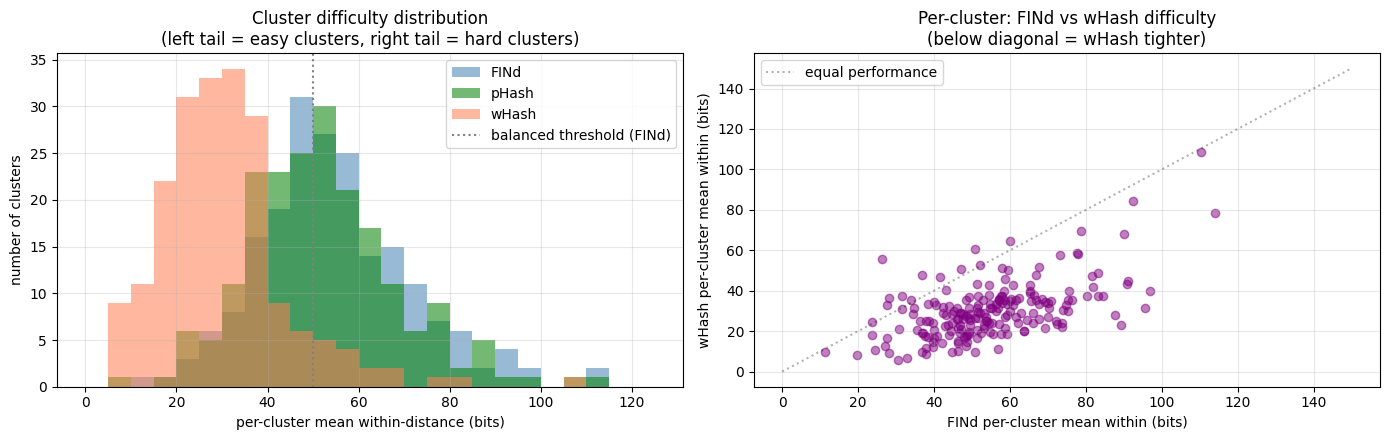

In [13]:
# Visualize: cluster difficulty distribution + per-method comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: histogram of per-cluster mean within-distance for each method
bins = np.arange(0, 130, 5)
for m_col, color, label in [('d_find_mean', 'steelblue', 'FINd'),
                              ('d_phash_mean', 'green', 'pHash'),
                              ('d_whash_mean', 'coral', 'wHash')]:
    axes[0].hist(cluster_stats[m_col], bins=bins, alpha=0.55, label=label, color=color)
axes[0].axvline(50, color='gray', linestyle=':', label='balanced threshold (FINd)')
axes[0].set_xlabel('per-cluster mean within-distance (bits)')
axes[0].set_ylabel('number of clusters')
axes[0].set_title('Cluster difficulty distribution\n(left tail = easy clusters, right tail = hard clusters)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: scatter — FINd vs wHash per-cluster mean
axes[1].scatter(cluster_stats.d_find_mean, cluster_stats.d_whash_mean, alpha=0.5, color='purple')
axes[1].plot([0, 150], [0, 150], 'k:', alpha=0.3, label='equal performance')
axes[1].set_xlabel('FINd per-cluster mean within (bits)')
axes[1].set_ylabel('wHash per-cluster mean within (bits)')
axes[1].set_title('Per-cluster: FINd vs wHash difficulty\n(below diagonal = wHash tighter)')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'per_cluster_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Method agreement matrix — at calibrated thresholds (FINd 90, pHash 90, wHash 60)
# i.e. each method's "balanced" operating point per its own distribution

balanced_thresh = {'find': 90, 'phash': 90, 'whash': 60}

within['find_says_dup']  = within['d_find']  < balanced_thresh['find']
within['phash_says_dup'] = within['d_phash'] < balanced_thresh['phash']
within['whash_says_dup'] = within['d_whash'] < balanced_thresh['whash']

agreement = (
    within.groupby(['find_says_dup', 'phash_says_dup', 'whash_says_dup'])
    .size()
    .reset_index(name='n_pairs')
    .sort_values('n_pairs', ascending=False)
)

print('Method agreement on TRUE within-pairs (1000 total):')
print('  Each row = (FINd verdict, pHash verdict, wHash verdict): n pairs')
print()
for _, row in agreement.iterrows():
    flags = (row['find_says_dup'], row['phash_says_dup'], row['whash_says_dup'])
    label = ' / '.join('YES' if f else 'no ' for f in flags)
    pct = row['n_pairs'] / len(within) * 100
    print(f'  FINd:{label.split(" / ")[0]} pHash:{label.split(" / ")[1]} wHash:{label.split(" / ")[2]}: {row["n_pairs"]:4d} pairs ({pct:5.1f}%)')

print()
unanimous_yes = agreement[(agreement.find_says_dup) & (agreement.phash_says_dup) & (agreement.whash_says_dup)]['n_pairs'].sum()
unanimous_no = agreement[(~agreement.find_says_dup) & (~agreement.phash_says_dup) & (~agreement.whash_says_dup)]['n_pairs'].sum()
disagreement = len(within) - unanimous_yes - unanimous_no
print(f'Summary: unanimous YES = {unanimous_yes} ({unanimous_yes/len(within)*100:.1f}%), '
      f'unanimous NO = {unanimous_no} ({unanimous_no/len(within)*100:.1f}%), '
      f'disagreement = {disagreement} ({disagreement/len(within)*100:.1f}%)')

Method agreement on TRUE within-pairs (1000 total):
  Each row = (FINd verdict, pHash verdict, wHash verdict): n pairs

  FINd:YES pHash:YES wHash:YES:  903 pairs ( 90.3%)
  FINd:YES pHash:YES wHash:no :   28 pairs (  2.8%)
  FINd:no  pHash:no  wHash:no :   28 pairs (  2.8%)
  FINd:no  pHash:no  wHash:YES:   20 pairs (  2.0%)
  FINd:no  pHash:YES wHash:YES:   16 pairs (  1.6%)
  FINd:no  pHash:YES wHash:no :    4 pairs (  0.4%)
  FINd:YES pHash:no  wHash:YES:    1 pairs (  0.1%)

Summary: unanimous YES = 903 (90.3%), unanimous NO = 28 (2.8%), disagreement = 69 (6.9%)


In [15]:
# Outlier inspection — within-pairs that surprised the algorithm (high distance)
# These are pairs where the dataset says "same meme cluster" but the hash says "different"

outliers = within.nlargest(10, 'd_find')[['file_a', 'file_b', 'cluster_a',
                                            'd_find', 'd_phash', 'd_whash']].copy()
outliers['method_agree_high'] = (
    (outliers.d_find > 90) & (outliers.d_phash > 90) & (outliers.d_whash > 60)
)

print('Top-10 within-pairs with highest FINd distance (algorithm says "different"):')
print('Method-agree-high column = True if all three methods agree this looks like between-pair')
print()
print(outliers.to_string(index=False))
print()
agree_count = outliers.method_agree_high.sum()
print(f'Of top 10 hardest within-pairs, {agree_count}/10 trigger ALL THREE methods to flag as "different"')
print('→ likely either heavy modifications (rotation/crop/heavy edit) OR label noise in the dataset')

Top-10 within-pairs with highest FINd distance (algorithm says "different"):
Method-agree-high column = True if all three methods agree this looks like between-pair

           file_a            file_b cluster_a  d_find  d_phash  d_whash  method_agree_high
0706_22163229.jpg 0706_32725051.jpg      0706     136      134       42              False
0526_13380953.jpg 0526_20007197.jpg      0526     134      134      120               True
0667_16355264.jpg 0667_21805010.jpg      0667     134      130      120               True
0667_18091759.jpg 0667_21805010.jpg      0667     132      124      138               True
0706_21828064.jpg 0706_29342550.jpg      0706     132      114       46              False
0086_22946703.jpg 0086_29916657.jpg      0086     130      130      110               True
0047_25674479.jpg 0047_29908354.jpg      0047     130      134      138               True
0864_27385689.jpg 0864_33895408.jpg      0864     130      124      106               True
0526_15406580.j

## 8. Computational cost comparison

We also need to compare **latency** between methods (Part 2 trade-off: accuracy vs speed). Measured on the same 100-image subset used in profile.ipynb.

In [16]:
# Use the same N=100 subset as profile.ipynb (seed=42)
from src.sampling import load_subset
subset = load_subset(IMG_DIR, n=100, seed=42)

cost_rows = []
for m, fn in methods.items():
    times = []
    for f in subset:
        t0 = time.perf_counter()
        fn(IMG_DIR / f)
        times.append(time.perf_counter() - t0)
    times = np.array(times)
    cost_rows.append({
        'method': m,
        'mean_ms': times.mean() * 1000,
        'median_ms': np.median(times) * 1000,
        'p95_ms': np.percentile(times, 95) * 1000,
        'std_ms': times.std() * 1000,
        'throughput_img_s': 1.0 / times.mean(),
    })
cost_df = pd.DataFrame(cost_rows).set_index('method')
print(cost_df.round(3).to_string())

        mean_ms  median_ms  p95_ms  std_ms  throughput_img_s
method                                                      
find      5.724      5.509   7.008   0.867           174.700
phash     1.972      1.865   2.728   0.409           507.064
whash     5.061      4.866   6.304   0.728           197.594


### Memory comparison

Use `tracemalloc` to measure peak Python-allocated memory per `fromFile` call. This complements `%memit` (which measures process RSS); tracemalloc is portable and gives a per-call delta without process-state noise.

In [17]:
import tracemalloc

mem_rows = []
warmup_path = IMG_DIR / subset[0]
for m, fn in methods.items():
    fn(warmup_path)  # warm up imports / lazy initialisation
    peaks = []
    for f in subset[:30]:
        tracemalloc.start()
        fn(IMG_DIR / f)
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        peaks.append(peak)
    peaks = np.array(peaks)
    mem_rows.append({
        'method': m,
        'peak_mean_MiB': peaks.mean() / 1024 / 1024,
        'peak_max_MiB': peaks.max() / 1024 / 1024,
        'peak_median_MiB': np.median(peaks) / 1024 / 1024,
    })
mem_df = pd.DataFrame(mem_rows).set_index('method')
print(mem_df.round(3).to_string())

        peak_mean_MiB  peak_max_MiB  peak_median_MiB
method                                              
find            2.905         2.944            2.944
phash           0.070         0.070            0.070
whash           0.539         0.539            0.539


## 9. Summary JSON + acceptance-bar fill

In [18]:
# Compose summary JSON for cross-version comparison
summary = {
    'seed': SEED,
    'n_within': len(within_pairs),
    'n_between': len(between_pairs),
    'n_clusters_used': N_WITHIN_CLUSTERS + N_BETWEEN_REPRESENTATIVES,
    'distributions': dist_df.reset_index().to_dict(orient='records'),
    'auc': {m: float(roc_data[m]['auc']) for m in methods},
    'operating_points': {
        m: {
            f'TPR_at_FPR_{int(t*1000)/10}pct': tpr_at_fpr(roc_data[m], t)[0]
            for t in target_fprs
        }
        for m in methods
    },
    'cost': cost_df.reset_index().to_dict(orient='records'),
    'memory': mem_df.reset_index().to_dict(orient='records'),
}

with open(SUMMARIES_DIR / 'accuracy_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved → summaries/accuracy_summary.json')

print()
print('=== ACCEPTANCE BAR FILL (for evaluation_criteria.md) ===')
print()
find_tpr_1pct, find_thr = tpr_at_fpr(roc_data['find'], 0.01)
phash_tpr_1pct, _ = tpr_at_fpr(roc_data['phash'], 0.01)
whash_tpr_1pct, _ = tpr_at_fpr(roc_data['whash'], 0.01)
discrimination_find = dist_df.loc['find', 'discrimination']
print(f'A1 (TPR @ FPR=1% ≥ 80% absolute + ≥ pHash−5pp):')
print(f'    FINd  TPR = {find_tpr_1pct*100:.1f}%   {"✓" if find_tpr_1pct >= 0.80 else "✗"} absolute')
print(f'    pHash TPR = {phash_tpr_1pct*100:.1f}%')
print(f'    Δ FINd vs pHash = {(find_tpr_1pct - phash_tpr_1pct)*100:+.1f} pp   {"✓" if find_tpr_1pct >= phash_tpr_1pct - 0.05 else "✗"} (≥ −5pp)')
print()
print(f'A3 (discrimination ≥ 50 bits):')
print(f'    FINd discrimination = {discrimination_find:.1f} bits   {"✓" if discrimination_find >= 50 else "✗"}')
print()
print(f'A6 (wHash exploratory, no formal bar):')
print(f'    wHash TPR @ FPR=1% = {whash_tpr_1pct*100:.1f}%')
print(f'    wHash AUC = {roc_data["whash"]["auc"]:.3f}')
print(f'    Δ wHash vs FINd = {(whash_tpr_1pct - find_tpr_1pct)*100:+.1f} pp')

Saved → summaries/accuracy_summary.json

=== ACCEPTANCE BAR FILL (for evaluation_criteria.md) ===

A1 (TPR @ FPR=1% ≥ 80% absolute + ≥ pHash−5pp):
    FINd  TPR = 97.2%   ✓ absolute
    pHash TPR = 97.1%
    Δ FINd vs pHash = +0.1 pp   ✓ (≥ −5pp)

A3 (discrimination ≥ 50 bits):
    FINd discrimination = 72.6 bits   ✓

A6 (wHash exploratory, no formal bar):
    wHash TPR @ FPR=1% = 96.3%
    wHash AUC = 0.992
    Δ wHash vs FINd = -0.9 pp


## 11. Adversarial robustness benchmark

Production content moderation faces **adversarial actors** who actively perturb images to evade hash detection (small noise overlays on banned content, slight crops/rotations to bypass copyright filters). Our headline accuracy benchmark measured *non-malicious* near-duplicates only — natural variations from re-encoding, resizing, watermark addition. This section adds an **adversarial axis** to the comparison.

**Hypothesis tested**: FINd's 256-bit hash space (vs pHash's 64-bit default) should give *measurable* resistance to bit-flipping attacks because more bits mean more independent samples to perturb simultaneously.

**Methodology**:
- Sample N=30 random images from the dataset (seed=99 — same seed as accuracy_benchmark)
- Apply 5 attack types per image:
  1. **Gaussian noise** σ=5 — high-frequency pixel-level perturbation
  2. **JPEG re-compression** quality=10 — lossy compression artefacts
  3. **Rotation** 3° — small geometric transform
  4. **Crop** 5% from each edge — framing perturbation
  5. **Brightness** +20% — luma shift
- For each (image, attack, method) compute `hash(original) - hash(attack(original))` (Hamming distance)
- Aggregate: mean distance per (attack × method)

**Lower distance = more robust** (hash is invariant to the attack).

In [19]:
# Adversarial benchmark — 5 attacks x 30 images x 3 methods
import io
import random
from PIL import Image as PILImage, ImageEnhance

ADV_SEED = 99
ADV_N_IMAGES = 30

random.seed(ADV_SEED)
np.random.seed(ADV_SEED)


# === Attack implementations ===

def attack_noise(img: PILImage.Image, sigma: float = 5.0) -> PILImage.Image:
    arr = np.asarray(img.convert('RGB'), dtype=np.float32)
    noise = np.random.normal(0, sigma, arr.shape)
    return PILImage.fromarray(np.clip(arr + noise, 0, 255).astype(np.uint8))


def attack_jpeg(img: PILImage.Image, quality: int = 10) -> PILImage.Image:
    buf = io.BytesIO()
    img.convert('RGB').save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return PILImage.open(buf)


def attack_rotate(img: PILImage.Image, degrees: float = 3.0) -> PILImage.Image:
    return img.rotate(degrees, fillcolor=(128, 128, 128))


def attack_crop(img: PILImage.Image, fraction: float = 0.05) -> PILImage.Image:
    w, h = img.size
    dx, dy = int(w * fraction), int(h * fraction)
    cropped = img.crop((dx, dy, w - dx, h - dy))
    return cropped.resize((w, h))


def attack_brightness(img: PILImage.Image, factor: float = 1.2) -> PILImage.Image:
    return ImageEnhance.Brightness(img).enhance(factor)


attacks = {
    'noise_sigma_5':       attack_noise,
    'jpeg_q10':            attack_jpeg,
    'rotate_3deg':         attack_rotate,
    'crop_5pct':           attack_crop,
    'brightness_+20pct':   attack_brightness,
}


# === Hashing helpers (need to handle both file-path and in-memory image) ===

def hash_pil_image(method_name: str, pil_img: PILImage.Image):
    if method_name == 'find':
        return find.fromImage(pil_img)
    elif method_name == 'phash':
        return imagehash.phash(pil_img, hash_size=16)
    elif method_name == 'whash':
        return imagehash.whash(pil_img, hash_size=16, mode='haar')


# === Sample 30 random images ===

all_files = sorted([f for f in IMG_DIR.iterdir() if f.suffix == '.jpg'])
adv_files = random.sample(all_files, ADV_N_IMAGES)
print(f'Adversarial sample: {len(adv_files)} images, seed={ADV_SEED}')


# === Run benchmark ===

results = []
for f in adv_files:
    img_orig = PILImage.open(f)
    # Hash original with each method
    hashes_orig = {m: hash_pil_image(m, img_orig.copy()) for m in methods}
    # Apply each attack and re-hash
    for attack_name, attack_fn in attacks.items():
        img_attacked = attack_fn(img_orig.copy())
        for m in methods:
            h_attacked = hash_pil_image(m, img_attacked)
            distance = hashes_orig[m] - h_attacked
            results.append({
                'file': f.name,
                'attack': attack_name,
                'method': m,
                'distance_after_attack': distance,
            })

adv_df = pd.DataFrame(results)
print(f'Computed {len(adv_df)} (image x attack x method) pairs')
adv_df.head()

Adversarial sample: 30 images, seed=99


Computed 450 (image x attack x method) pairs


,file,attack,method,distance_after_attack
0,0263_10831990.jpg,noise_sigma_5,find,0
1,0263_10831990.jpg,noise_sigma_5,phash,0
2,0263_10831990.jpg,noise_sigma_5,whash,0
3,0263_10831990.jpg,jpeg_q10,find,4
4,0263_10831990.jpg,jpeg_q10,phash,6


In [20]:
# Aggregate: mean Hamming distance per (attack x method)
summary_table = adv_df.groupby(['attack', 'method'])['distance_after_attack'].agg(['mean', 'std', 'max']).round(1)
summary_table_pivot = adv_df.groupby(['attack', 'method'])['distance_after_attack'].mean().unstack().round(1)

print('=== Mean Hamming distance after attack (lower = more robust) ===')
print(summary_table_pivot.to_string())
print()
print('=== Per-attack winner (smallest mean distance) ===')
for attack_name in adv_df['attack'].unique():
    row = summary_table_pivot.loc[attack_name]
    winner = row.idxmin()
    print(f'  {attack_name:25s}: {winner} ({row[winner]:.1f} bits)')

print()
print('=== Detailed std + max per attack/method ===')
print(summary_table.to_string())

=== Mean Hamming distance after attack (lower = more robust) ===
method             find  phash  whash
attack                               
brightness_+20pct   8.8    9.5    9.8
crop_5pct          81.7   75.7   41.3
jpeg_q10            6.9    5.5    4.8
noise_sigma_5       1.5    1.0    2.6
rotate_3deg        53.5   47.6   28.8

=== Per-attack winner (smallest mean distance) ===
  noise_sigma_5            : phash (1.0 bits)
  jpeg_q10                 : whash (4.8 bits)
  rotate_3deg              : whash (28.8 bits)
  crop_5pct                : whash (41.3 bits)
  brightness_+20pct        : find (8.8 bits)

=== Detailed std + max per attack/method ===
                          mean   std  max
attack            method                 
brightness_+20pct find     8.8   3.9   20
                  phash    9.5   4.2   16
                  whash    9.8   8.3   37
crop_5pct         find    81.7  13.3  106
                  phash   75.7  12.5  100
                  whash   41.3  18.0  116
jpeg

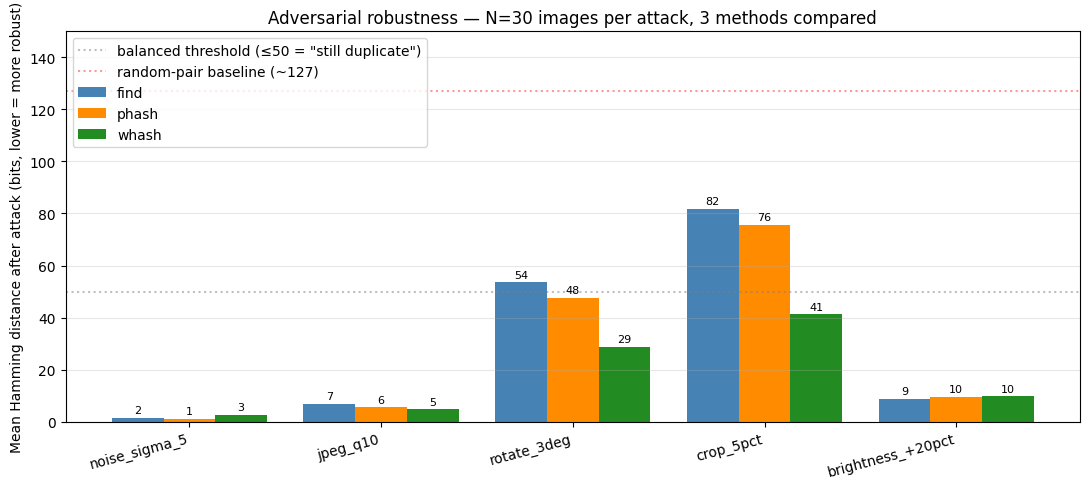

In [21]:
# Visualise: bar chart per attack with method comparison
fig, ax = plt.subplots(figsize=(11, 5))

attack_names = list(attacks.keys())
method_colors = {'find': 'steelblue', 'phash': 'darkorange', 'whash': 'forestgreen'}
x = np.arange(len(attack_names))
width = 0.27

for i, m in enumerate(methods):
    means = [summary_table_pivot.loc[a, m] for a in attack_names]
    bars = ax.bar(x + (i - 1) * width, means, width, label=m, color=method_colors[m])
    for b, val in zip(bars, means):
        ax.text(b.get_x() + b.get_width() / 2, val + 1, f'{val:.0f}',
                ha='center', va='bottom', fontsize=8)

# Reference lines
ax.axhline(50, color='gray', linestyle=':', alpha=0.5, label='balanced threshold (≤50 = "still duplicate")')
ax.axhline(127, color='red', linestyle=':', alpha=0.4, label='random-pair baseline (~127)')

ax.set_xticks(x)
ax.set_xticklabels(attack_names, rotation=15, ha='right')
ax.set_ylabel('Mean Hamming distance after attack (bits, lower = more robust)')
ax.set_title(f'Adversarial robustness — N={ADV_N_IMAGES} images per attack, 3 methods compared')
ax.legend(loc='upper left')
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 150)

fig.tight_layout()
fig.savefig(FIG_DIR / 'adversarial_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Interpretation: which method wins by attack category
print('=== Robustness ranking (lower mean distance = more robust) ===')
ranks = {}
for attack_name in attacks:
    row = summary_table_pivot.loc[attack_name].sort_values()
    ranks[attack_name] = list(row.index)
    print(f'{attack_name:25s}: {" > ".join(row.index)}  '
          f'(distances: {row.values.round(1).tolist()})')

print()
print('=== FINd specifically: does 256-bit hash advantage materialise? ===')
for attack_name in attacks:
    find_d = summary_table_pivot.loc[attack_name, 'find']
    phash_d = summary_table_pivot.loc[attack_name, 'phash']
    delta = phash_d - find_d
    direction = 'FINd more robust' if delta > 0 else 'pHash more robust' if delta < 0 else 'tied'
    print(f'  {attack_name:25s}: FINd={find_d:5.1f}  pHash={phash_d:5.1f}  Δ={delta:+5.1f}  → {direction}')

# Save adversarial summary to JSON
adversarial_summary = {
    'seed': ADV_SEED,
    'n_images': ADV_N_IMAGES,
    'attacks': list(attacks.keys()),
    'mean_distance': summary_table_pivot.to_dict(),
    'std_distance': summary_table.unstack()['std'].to_dict() if 'std' in summary_table.columns else {},
    'per_attack_winner': {a: summary_table_pivot.loc[a].idxmin() for a in attacks},
}

with open(SUMMARIES_DIR / 'adversarial_summary.json', 'w') as f:
    json.dump(adversarial_summary, f, indent=2, default=str)
print()
print('Saved → summaries/adversarial_summary.json')

=== Robustness ranking (lower mean distance = more robust) ===
noise_sigma_5            : phash > find > whash  (distances: [1.0, 1.5, 2.6])
jpeg_q10                 : whash > phash > find  (distances: [4.8, 5.5, 6.9])
rotate_3deg              : whash > phash > find  (distances: [28.8, 47.6, 53.5])
crop_5pct                : whash > phash > find  (distances: [41.3, 75.7, 81.7])
brightness_+20pct        : find > phash > whash  (distances: [8.8, 9.5, 9.8])

=== FINd specifically: does 256-bit hash advantage materialise? ===
  noise_sigma_5            : FINd=  1.5  pHash=  1.0  Δ= -0.5  → pHash more robust
  jpeg_q10                 : FINd=  6.9  pHash=  5.5  Δ= -1.4  → pHash more robust
  rotate_3deg              : FINd= 53.5  pHash= 47.6  Δ= -5.9  → pHash more robust
  crop_5pct                : FINd= 81.7  pHash= 75.7  Δ= -6.0  → pHash more robust
  brightness_+20pct        : FINd=  8.8  pHash=  9.5  Δ= +0.7  → FINd more robust

Saved → summaries/adversarial_summary.json


## 10. Export this run as HTML report

Self-contained `reports/accuracy/accuracy_report.html` — go in Part 2 PDF or share with reviewer.

In [23]:
import subprocess

report_dir = PROJECT_ROOT / 'reports' / 'accuracy'
report_dir.mkdir(parents=True, exist_ok=True)

result = subprocess.run(
    ['jupyter', 'nbconvert', '--to', 'html',
     str(PROJECT_ROOT / 'notebooks' / 'accuracy_benchmark.ipynb'),
     '--output-dir', str(report_dir),
     '--output', 'accuracy_report.html'],
    capture_output=True, text=True,
)
if result.returncode != 0:
    print('ERROR:', result.stderr)
else:
    print(result.stdout.strip() or 'OK')
    print(f'HTML report → {(report_dir / "accuracy_report.html").relative_to(PROJECT_ROOT)}')

OK
HTML report → reports/accuracy/accuracy_report.html
